### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [3]:
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

df_total = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

In [4]:
faturamento = df_total.groupby('Loja')['Preço'].sum()

In [17]:
faturamento_final = faturamento.reset_index().sort_values('Preço', ascending=False)
display(faturamento_final)

,Loja,Preço
0,Loja 1,1534509.12
1,Loja 2,1488459.06
2,Loja 3,1464025.03
3,Loja 4,1384497.58


# 2. Vendas por Categoria

In [12]:
vendas_por_categoria = df_total.groupby(['Loja', 'Categoria do Produto']).size()

In [16]:
vendas_final = vendas_por_categoria.reset_index(name='Total Vendido')
vendas_final = vendas_final.sort_values(['Loja', 'Total Vendido'], ascending=[True, False])

display(vendas_final)

,Loja,Categoria do Produto,Total Vendido
6,Loja 1,moveis,465
2,Loja 1,eletronicos,448
0,Loja 1,brinquedos,324
1,Loja 1,eletrodomesticos,312
3,Loja 1,esporte e lazer,284
4,Loja 1,instrumentos musicais,182
5,Loja 1,livros,173
7,Loja 1,utilidades domesticas,171
14,Loja 2,moveis,442
10,Loja 2,eletronicos,422


# 3. Média de Avaliação das Lojas


In [18]:
df_total.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


In [20]:
avaliacao_por_loja = df_total.groupby('Loja')['Avaliação da compra'].mean()
display(avaliacao_por_loja)

,Avaliação da compra
Loja,
Loja 1,3.976685
Loja 2,4.037304
Loja 3,4.048326
Loja 4,3.995759


# 4. Produtos Mais e Menos Vendidos

In [22]:
contagem_produtos = df_total.groupby(['Loja', 'Produto']).size().reset_index(name='Total Vendas')
contagem_produtos = contagem_produtos.sort_values(['Loja', 'Total Vendas'], ascending=[True, False])

In [24]:
produtos_mais_vendidos = contagem_produtos.groupby('Loja').head(3)
produtos_menos_vendidos = contagem_produtos.groupby('Loja').tail(3)

display(produtos_mais_vendidos)
display(produtos_menos_vendidos)

,Loja,Produto,Total Vendas
24,Loja 1,Guarda roupas,60
37,Loja 1,Micro-ondas,60
47,Loja 1,TV Led UHD 4K,60
79,Loja 2,Iniciando em programação,65
88,Loja 2,Micro-ondas,62
52,Loja 2,Bateria,61
134,Loja 3,Kit banquetas,57
111,Loja 3,Cama king,56
138,Loja 3,Mesa de jantar,56
161,Loja 4,Cama box,62


,Loja,Produto,Total Vendas
41,Loja 1,Panela de pressão,35
11,Loja 1,Celular ABXY,33
26,Loja 1,Headset,33
78,Loja 2,Impressora,34
87,Loja 2,Mesa de jantar,34
82,Loja 2,Jogo de tabuleiro,32
139,Loja 3,Micro-ondas,36
140,Loja 3,Mochila,36
105,Loja 3,Blocos de montar,35
202,Loja 4,Violão,37


# 5. Frete Médio por Loja

In [25]:
df_total.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


In [28]:
frete_medio = df_total.groupby('Loja')['Frete'].mean()
display(frete_medio)

,Frete
Loja,
Loja 1,34.691805
Loja 2,33.621941
Loja 3,33.074464
Loja 4,31.278997


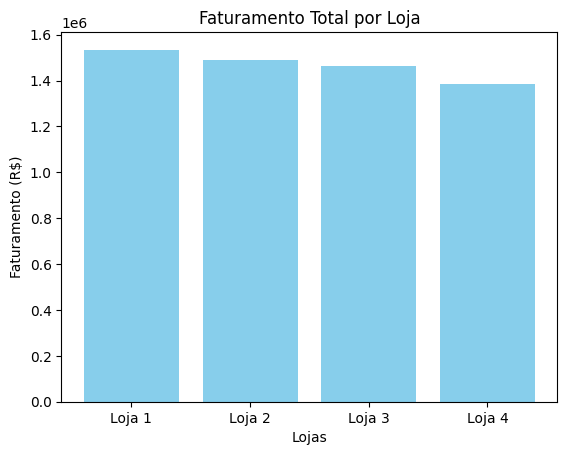

In [29]:
import matplotlib.pyplot as plt

plt.bar(faturamento_final['Loja'], faturamento_final['Preço'], color='skyblue')
plt.title('Faturamento Total por Loja')
plt.xlabel('Lojas')
plt.ylabel('Faturamento (R$)')
plt.show()

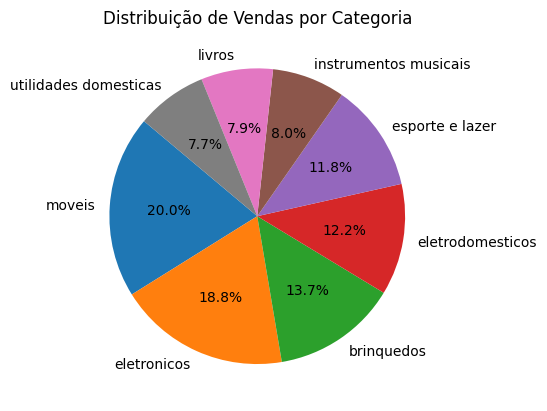

In [30]:
categorias_geral = df_total['Categoria do Produto'].value_counts()

plt.pie(categorias_geral, labels=categorias_geral.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição de Vendas por Categoria')
plt.show()

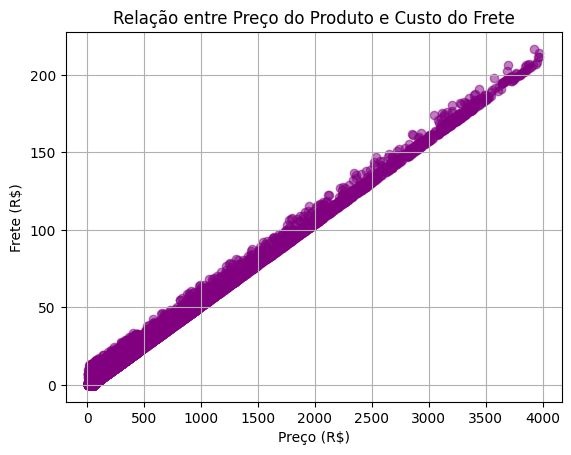

In [31]:
plt.scatter(df_total['Preço'], df_total['Frete'], alpha=0.5, color='purple')
plt.title('Relação entre Preço do Produto e Custo do Frete')
plt.xlabel('Preço (R$)')
plt.ylabel('Frete (R$)')
plt.grid(True)
plt.show()

# **1. O que foi analisado?**
*Faturamento, custo de frete e satisfação do cliente em todas as unidades.*

# **2. Desempenho das Lojas**

**Vendas:** *A Loja 4 é a menos lucrativa, com faturamento de R$ 1.384.497,58 (ficando em último lugar).*

**Logística:** *O frete da Loja 4 é o mais barato (R$ 31,27), mas isso não foi suficiente para atrair vendas volumosas.*

**Satisfação:** *Todas as lojas têm notas parecidas (em torno de 4.0), o que mostra que o problema da Loja 4 não é a qualidade, mas a falta de demanda.*

# **3. Recomendação Final: Vender a Loja 4**
**Justificativa:*  *A Loja 4 deve ser vendida por ser a unidade menos eficiente. Mesmo com o frete mais ba ixo de toda a rede, ela não consegue converter isso em vendas altas. É mais vantajoso vender essa operação e focar os investimentos na Loja 1, que é a líder absoluta de faturamento.*